In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

In [62]:
# ── CONFIG: point this to your training_logs folder ──────────────────────────
LOG_DIR = Path("/Users/shamiksinha/Desktop/SafeTail-2.0/src/logs")
TARGET_LATENCY_S = 1.2   # red dashed line (seconds)
PERCENTILES = [50, 90, 95, 99]
# ─────────────────────────────────────────────────────────────────────────────

In [63]:
def load_latencies(mode: str) -> np.ndarray:
    """Read total_latency column from a mode's CSV and return in seconds."""
    path = LOG_DIR / f"{mode}_latency_log.csv"
    if not path.exists():
        print(f"[WARN] {path} not found — skipping {mode}")
        return None
    df = pd.read_csv(path)
    return df["total_latency"].dropna().values / 1000.0  # ms → seconds

def get_percentiles(latencies: np.ndarray) -> list:
    if latencies is None or len(latencies) == 0:
        return [np.nan] * len(PERCENTILES)
    return [np.percentile(latencies, p) for p in PERCENTILES]

In [64]:
# Load all modes
modes = [
    "safetail",
    "minload_1", "minload_2", "minload_3",
    "minprop_1", "minprop_2", "minprop_3",
    "rand_1",    "rand_2",    "rand_3",
]

raw = {mode: load_latencies(mode) for mode in modes}

# Truncate all to the minimum number of entries among available CSVs
available = {m: v for m, v in raw.items() if v is not None}
min_count = min(len(v) for v in available.values())
print(f"Entry counts per mode: { {m: len(v) for m, v in available.items()} }")
print(f"Truncating all to {min_count} entries for fair comparison.\n")

truncated = {m: v[:min_count] for m, v in available.items()}

# Compute percentiles
data = {mode: get_percentiles(truncated.get(mode)) for mode in modes}

# Print summary table
labels = [f"{p}%tile" for p in PERCENTILES]
df_summary = pd.DataFrame(
    {m: data[m] for m in modes if not all(np.isnan(data[m]))},
    index=labels
)
print(df_summary.round(4).to_string())

[WARN] /Users/shamiksinha/Desktop/SafeTail-2.0/src/logs/rand_1_latency_log.csv not found — skipping rand_1
[WARN] /Users/shamiksinha/Desktop/SafeTail-2.0/src/logs/rand_2_latency_log.csv not found — skipping rand_2
[WARN] /Users/shamiksinha/Desktop/SafeTail-2.0/src/logs/rand_3_latency_log.csv not found — skipping rand_3
Entry counts per mode: {'safetail': 13520, 'minload_1': 11944, 'minload_2': 12242, 'minload_3': 23964, 'minprop_1': 12064, 'minprop_2': 11928, 'minprop_3': 12056}
Truncating all to 11928 entries for fair comparison.

         safetail  minload_1  minload_2  minload_3  minprop_1  minprop_2  minprop_3
50%tile    0.0312     0.0496     0.0410     0.0318     0.0304     0.0299     0.0299
90%tile    0.0514     0.1176     0.0759     0.0496     0.0486     0.0470     0.0469
95%tile    0.0656     0.1374     0.0952     0.0526     0.0511     0.0492     0.0491
99%tile    0.1131     0.1649     0.1267     0.0614     0.0648     0.0532     0.0527


In [65]:
def plot_comparison(ax, group_modes, group_labels, colors, hatches, title):
    n_groups = len(PERCENTILES)
    n_bars   = len(group_modes)
    bar_w    = 0.15
    x        = np.arange(n_groups)

    for i, (mode, label, color, hatch) in enumerate(zip(group_modes, group_labels, colors, hatches)):
        vals = data[mode]
        offset = (i - n_bars / 2 + 0.5) * bar_w
        ax.bar(x + offset, vals, width=bar_w,
               label=label, color=color, hatch=hatch, edgecolor="black", linewidth=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{p}%tile" for p in PERCENTILES])
    ax.set_xlabel("Percentile")
    ax.set_ylabel("Total latency (s)")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_ylim(bottom=0)

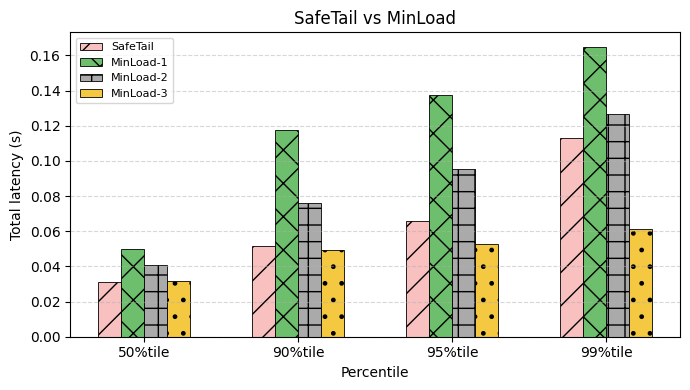

In [66]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_comparison(
    ax,
    group_modes  = ["safetail", "minload_1", "minload_2", "minload_3"],
    group_labels = ["SafeTail", "MinLoad-1", "MinLoad-2", "MinLoad-3"],
    colors       = ["#f9c0c0", "#6dbf6d", "#aaaaaa", "#f5c842"],
    hatches      = ["/", "x", "+", "."],
    title        = "SafeTail vs MinLoad"
)
plt.tight_layout()
plt.show()

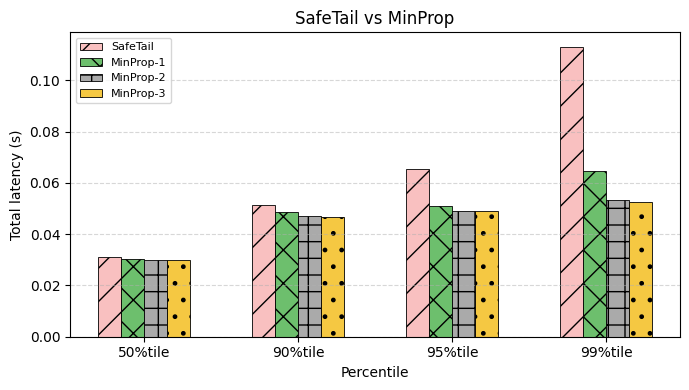

In [67]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_comparison(
    ax,
    group_modes  = ["safetail", "minprop_1", "minprop_2", "minprop_3"],
    group_labels = ["SafeTail", "MinProp-1", "MinProp-2", "MinProp-3"],
    colors       = ["#f9c0c0", "#6dbf6d", "#aaaaaa", "#f5c842"],
    hatches      = ["/", "x", "+", "."],
    title        = "SafeTail vs MinProp"
)
plt.tight_layout()
plt.show()

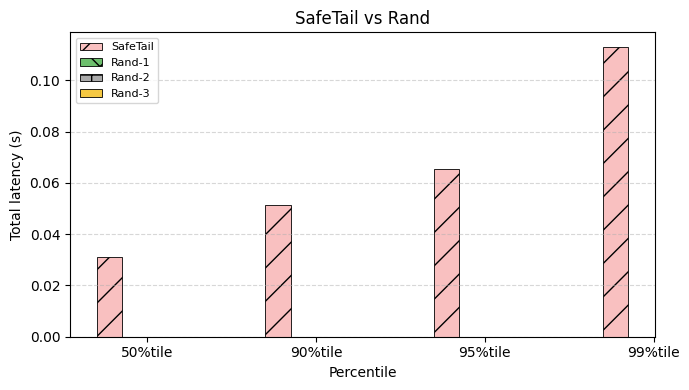

In [68]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_comparison(
    ax,
    group_modes  = ["safetail", "rand_1", "rand_2", "rand_3"],
    group_labels = ["SafeTail", "Rand-1", "Rand-2", "Rand-3"],
    colors       = ["#f9c0c0", "#6dbf6d", "#aaaaaa", "#f5c842"],
    hatches      = ["/", "x", "+", "."],
    title        = "SafeTail vs Rand"
)
plt.tight_layout()
plt.show()

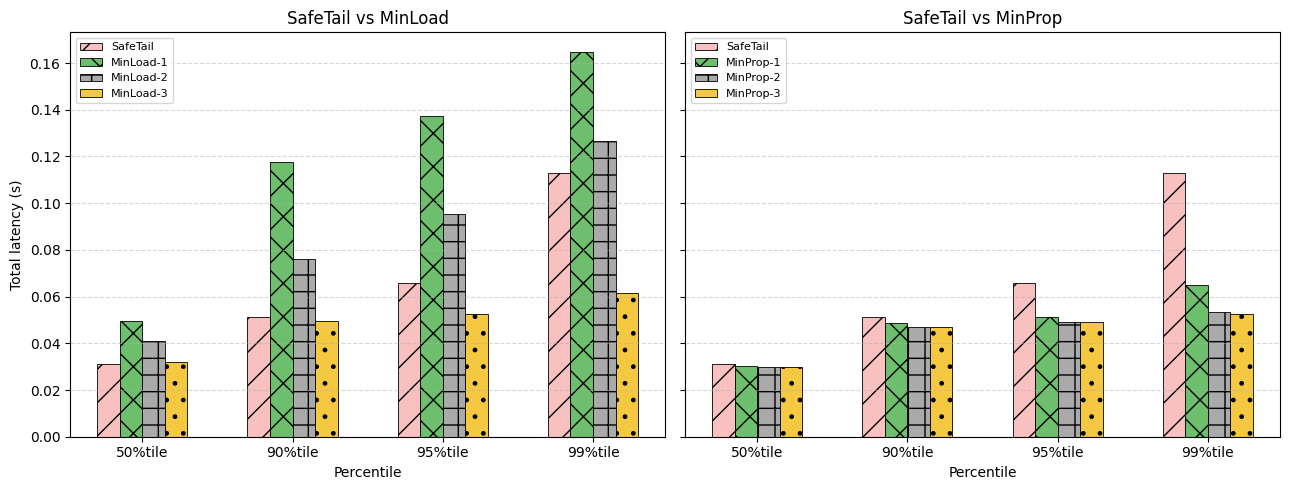

In [69]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
plot_comparison(
    ax1,
    group_modes  = ["safetail", "minload_1", "minload_2", "minload_3"],
    group_labels = ["SafeTail", "MinLoad-1", "MinLoad-2", "MinLoad-3"],
    colors       = ["#f9c0c0", "#6dbf6d", "#aaaaaa", "#f5c842"],
    hatches      = ["/", "x", "+", "."],
    title        = "SafeTail vs MinLoad"
)
plot_comparison(
    ax2,
    group_modes  = ["safetail", "minprop_1", "minprop_2", "minprop_3"],
    group_labels = ["SafeTail", "MinProp-1", "MinProp-2", "MinProp-3"],
    colors       = ["#f9c0c0", "#6dbf6d", "#aaaaaa", "#f5c842"],
    hatches      = ["/", "x", "+", "."],
    title        = "SafeTail vs MinProp"
)
ax2.set_ylabel("")
plt.tight_layout()
plt.show()